In [2]:
import random
import networkx as nx
import torch
import torch.nn as nn

from deep_ebm.utils_ebm import show_graph, evaluate_model
from deep_ebm.utils_ebm import save_graph, compare_graphs, show_graph_grid, compare_statistics
from deep_ebm.gnn_ebm import GraphDataset, GNN_EBM, train_one_epoch_pcd, gibbs_ministeps

from src.torch_erg import load_pglib_opf as lp
from src.torch_erg.samplers import GWGSampler, MHSampler, GWG_Hybrid_Sampler, MH_Hybrid_Sampler
from src.torch_erg.utils import laplacian_matrix,  unif_move, index_ravel_sampler
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle as pkl
from scipy.sparse.csgraph import connected_components
from scipy.sparse import csr_matrix

from Plots_and_utils.plots import *
from Plots_and_utils.other_g_stats import *

from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [3]:
with open("Saved_models/2community_GNN_EBM_50e_2000GS.pkl", "rb") as f:
    model_deep= pkl.load(f)
with open("data/TOY2community_dataset/TOY2comms_GraphDataset.pkl", "rb") as f:
    dataset_2community = pkl.load(f)

In [4]:
reference = dataset_2community[0][0]
ref_feats = dataset_2community[0][1]
model_deep(ref_feats, reference)

tensor(188.6816, grad_fn=<SqueezeBackward0>)

In [5]:
class MySampler(GWG_Hybrid_Sampler):
    def __init__(self, backend: str, model: nn.Module):
        super().__init__(backend, model)
        self.model = model
    def observables(self, mtx):
        edges = torch.sum(mtx)/2
        triangles = torch.trace(torch.matmul(torch.matmul(mtx,mtx),mtx))/6
        #ac = torch.linalg.eigvalsh(laplacian_matrix(mtx))[1]
        return(torch.stack([edges, triangles]))
        
betas = torch.tensor([0., 0.])


In [6]:
#we freeze the node features as we do not need them, so that we can evaluate the model only on the adj matrix
class feat_encoded_model(nn.Module):
    def __init__(self, model, feats):
        super().__init__()
        self.model = model
        self.feats = feats.to(device)

    def forward(self,adj):
        return(self.model(self.feats, adj))

In [7]:
adj_model = feat_encoded_model(model_deep, ref_feats)
sampler = MySampler(backend="cuda",model = adj_model)
obs = sampler.observables(reference)
print("observed observables: ", obs)

CUDA backend not available falling back to cpu
observed observables:  tensor([109., 127.])


In [8]:
mean_obs_deep = torch.Tensor([112.25, 125.73])

In [58]:
params, _ = sampler.param_run(graph=reference,
                      observables=obs,
                      params=last_betas,
                      niter=50000,
                      params_update_every=3,
                      save_every=50,
                      save_params=True,
                      alpha=0.001,                      
                      min_change = 0.001)

100%|██████████| 50000/50000 [03:16<00:00, 254.81it/s]

number of accepted steps is:  24923
number of rejected samples:  25077
number of effective updates is:  8307


In [60]:
last_betas = params[-1]
last_betas

tensor([-0.3266,  0.0995])

In [53]:
plot_params_iterations(params)


NameError: name 'params' is not defined

In [9]:
paramas_for_estimate = torch.Tensor([-0.3552,  0.1048])
paramas_for_estimate

tensor([-0.3552,  0.1048])

In [10]:
observables, graphs = sampler.sample_run(graph=reference,
                      observables=mean_obs_deep,
                      params=paramas_for_estimate,
                      niter=200000,
                      save_every=50,
                      burn_in=0.2)

  0%|          | 0/200000 [00:00<?, ?it/s]

100%|██████████| 200000/200000 [13:18<00:00, 250.37it/s]

number of accepted steps is:  107977
number of rejected samples:  92023
Mean obs:  tensor([131.9558, 246.8474])


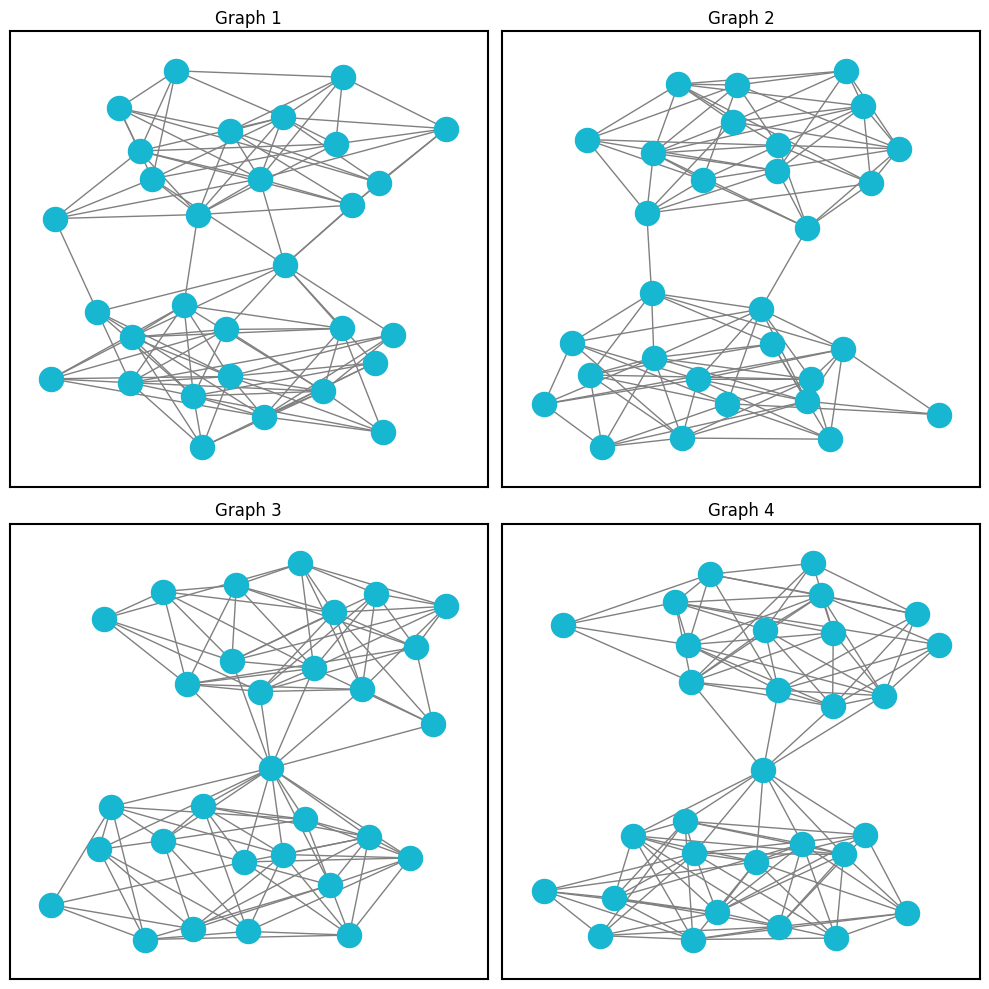

In [51]:
plot_random_graphs(graphs)

In [13]:
variation_obs = mean_obs_deep - torch.Tensor([0., 15])
variation_obs

tensor([112.2500, 110.7300])

In [14]:
init_betas = torch.tensor([0.,  0.])
params_v, _ = sampler.param_run(graph=reference,
                      observables=variation_obs,
                      params=init_betas,
                      niter=200000,
                      params_update_every=3,
                      save_every=50,
                      save_params=True,
                      alpha=0.001,                      
                      min_change = 0.001)

100%|██████████| 200000/200000 [13:02<00:00, 255.64it/s]

number of accepted steps is:  90909
number of rejected samples:  109091
number of effective updates is:  30303


In [ ]:
init_betas = torch.tensor([0.,  0.])
params_v, _ = sampler.param_run(graph=reference,
                      observables=variation_obs,
                      params=params_v[-1],
                      niter=50000,
                      params_update_every=3,
                      save_every=50,
                      save_params=True,
                      alpha=0.0001,                      
                      min_change = 0.001)

100%|██████████| 50000/50000 [03:13<00:00, 258.11it/s]

number of accepted steps is:  19762
number of rejected samples:  30238
number of effective updates is:  6587


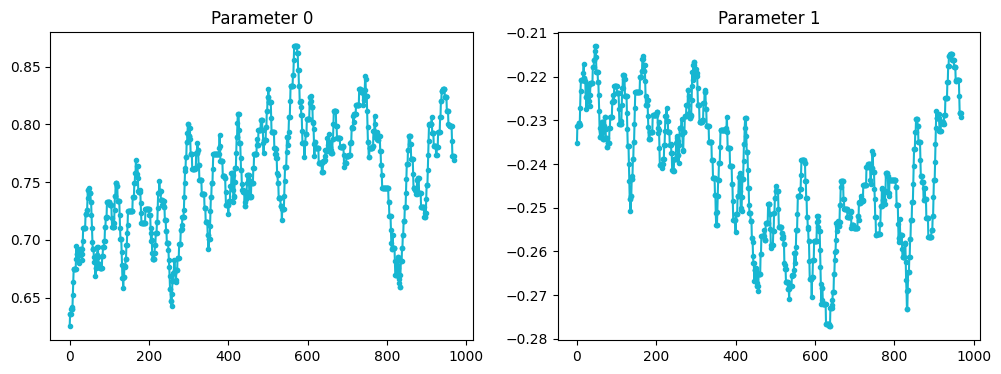

In [21]:
plot_params_iterations(params_v)

In [22]:
params_for_estimate_v = torch.stack(params_v[-1000:]).mean(0)
params_for_estimate_v

tensor([ 0.7529, -0.2417])

In [50]:
observables, graphs = sampler.sample_run(graph=reference,
                      observables=sampler.observables(reference),
                      params=params_for_estimate_v,
                      niter=50000,
                      save_every=50,
                      burn_in=0.2)

100%|██████████| 50000/50000 [04:35<00:00, 181.53it/s]

number of accepted steps is:  19810
number of rejected samples:  30190
Mean obs:  tensor([112.8938, 114.6738])


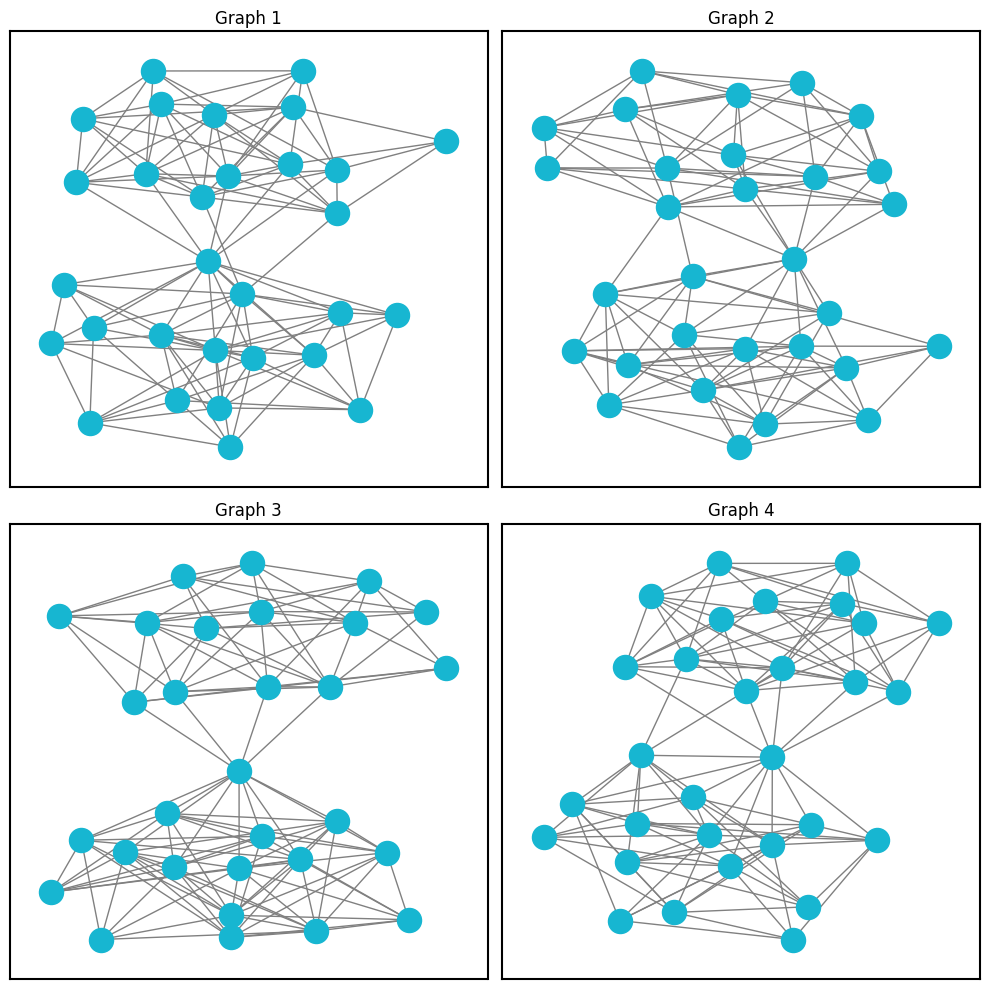

In [52]:
plot_random_graphs(graphs, layout="kamada")

---

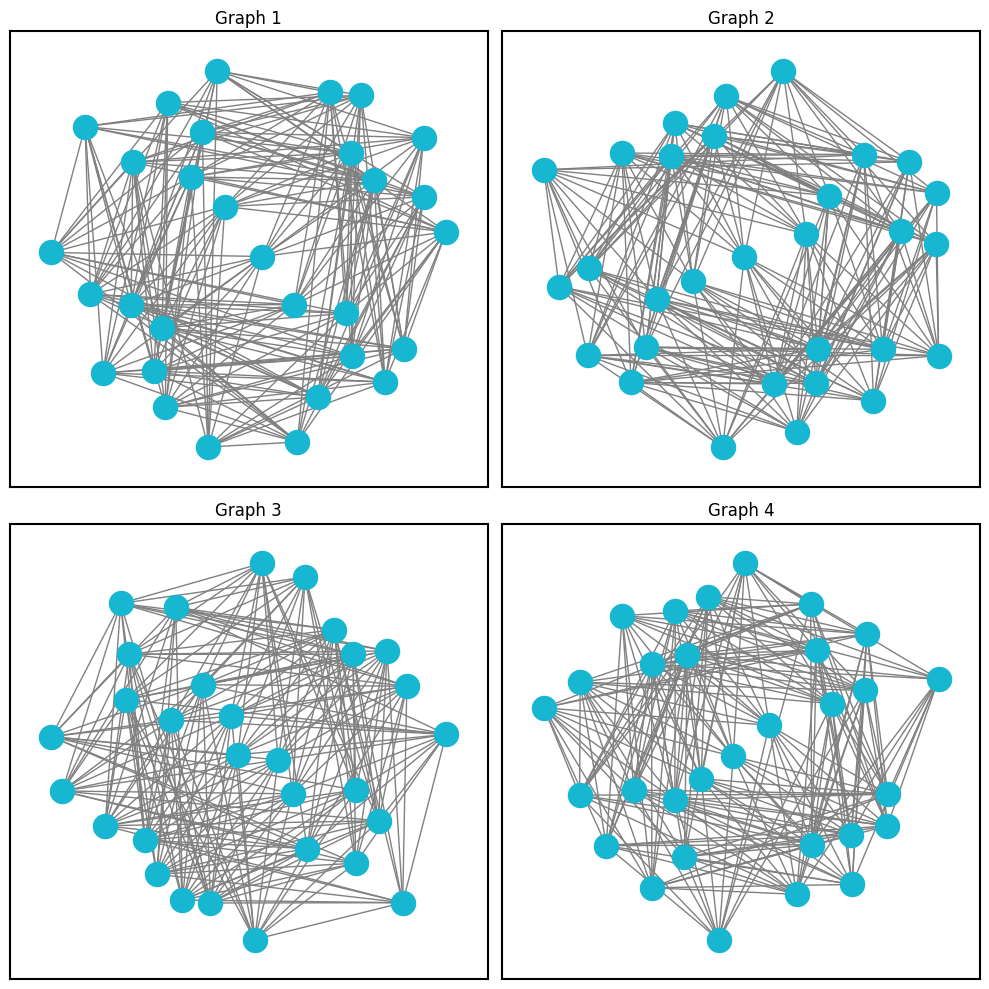

In [49]:
plot_random_graphs(graphs, layout="kamada")